# ATLAS — CREPE Pitch Extraction & Analysis

**What this notebook does:**
1. Extracts F0 (fundamental frequency) contours using CREPE
2. Computes pitch statistics per utterance (mean, std, range, vibrato rate)
3. Correlates F0 characteristics with phoneme-level technique annotations
4. Compares pitch behaviour across singing vs speech
5. Visualises F0 contours with technique annotations overlaid

**Key research question:** Do phonemes annotated with vibrato/glissando show measurably different F0 characteristics?

## 0. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Configuration

In [ ]:
from pathlib import Path

# ── Google Drive paths ────────────────────────────────────────────────────────
PROJECT_DIR   = Path("/content/drive/MyDrive/atlas")
META_CSV      = PROJECT_DIR / "metadata2" / "atlas_english_metadata.csv"
DRIVE_RESULTS = PROJECT_DIR / "results"
META_DIR      = PROJECT_DIR / "metadata2"

# ── Local paths ───────────────────────────────────────────────────────────────
LOCAL_DIR     = Path("/content/atlas")
EXTRACT_DIR   = LOCAL_DIR / "English_raw"
CREPE_DIR     = LOCAL_DIR / "crepe_results"

for d in [CREPE_DIR, DRIVE_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Settings ──────────────────────────────────────────────────────────────────
CREPE_MODEL   = "tiny"    # tiny/small/medium/large/full
CREPE_STEP    = 10        # step size in ms (10ms = 100 frames/sec)
SAMPLE_SIZE   = 200       # utterances to process (None = all)

print(f"META_CSV exists : {META_CSV.exists()}")
print(f"CREPE model     : {CREPE_MODEL}")
print(f"Step size       : {CREPE_STEP}ms")

META_CSV exists : True
CREPE model     : tiny
Step size       : 10ms


## 2. Install Dependencies

In [ ]:
!pip install -q crepe librosa tgt pandas matplotlib scipy
!apt-get install -y -q ffmpeg

import crepe
import librosa
import tgt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import signal
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("Dependencies ready")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 70.7 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Dependencies ready


## 3. Unzip Dataset (if needed)

In [ ]:
import zipfile

ZIP_PATH = PROJECT_DIR / "English.zip"
already_extracted = EXTRACT_DIR.exists() and any(EXTRACT_DIR.rglob("*.wav"))

if already_extracted:
    print(f"Already extracted")
else:
    print("Unzipping...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        from tqdm.notebook import tqdm as tqdm_nb
        for member in tqdm_nb(zf.namelist(), desc="Extracting"):
            zf.extract(member, EXTRACT_DIR)
    print("Done")

Unzipping...


Extracting:   0%|          | 0/25984 [00:00<?, ?it/s]

Done


## 4. Load Metadata

In [ ]:
import pandas as pd

df = pd.read_csv(META_CSV)

# Keep utterances with TextGrid (needed for technique annotations)
df = df[df["has_textgrid"] == True].copy().reset_index(drop=True)

print(f"Total utterances with TextGrid: {len(df):,}")
print(f"Groups: {sorted(df['group'].unique())}")

# Sample for speed if needed
if SAMPLE_SIZE is not None:
    # Stratified sample — equal per group
    df = (
        df.groupby("group", group_keys=False)
        .apply(lambda x: x.sample(min(len(x), SAMPLE_SIZE // 3), random_state=42))
        .reset_index(drop=True)
    )
    print(f"\nSampled: {len(df)} utterances ({SAMPLE_SIZE//3} per group)")

print(df.groupby("group")["wav_path"].count())

Total utterances with TextGrid: 5,209
Groups: ['control', 'speech', 'technique']

Sampled: 198 utterances (66 per group)
group
control      66
speech       66
technique    66
Name: wav_path, dtype: int64


## 5. CREPE F0 Extraction

CREPE (Convolutional Representation for Pitch Estimation) extracts frame-level F0 with confidence scores.

In [ ]:
def extract_f0(wav_path: str, model: str = "tiny", step_size: int = 10) -> dict:
    """Extract F0 contour using CREPE."""
    try:
        audio, sr = librosa.load(wav_path, sr=16000, mono=True)
        time, frequency, confidence, _ = crepe.predict(
            audio, sr,
            model_capacity=model,
            step_size=step_size,
            viterbi=True,
            verbose=0
        )
        # Mask low-confidence frames
        voiced = confidence > 0.5
        f0_voiced = frequency.copy()
        f0_voiced[~voiced] = np.nan

        return {
            "time":       time,
            "f0":         frequency,
            "f0_voiced":  f0_voiced,
            "confidence": confidence,
            "voiced":     voiced,
        }
    except Exception as e:
        return None


def f0_stats(f0_voiced: np.ndarray) -> dict:
    """Compute summary statistics from F0 contour."""
    valid = f0_voiced[~np.isnan(f0_voiced)]
    if len(valid) < 10:
        return {}

    # Convert to semitones for perceptually meaningful range
    f0_st = 12 * np.log2(valid / 440.0 + 1e-8)

    # Vibrato detection: std of F0 over short windows
    # High std in short windows = periodic oscillation = vibrato
    window_std = []
    win = 20  # 200ms window at 10ms step
    for i in range(0, len(valid) - win, win // 2):
        window_std.append(np.std(valid[i:i+win]))

    return {
        "f0_mean_hz":    float(np.mean(valid)),
        "f0_std_hz":     float(np.std(valid)),
        "f0_range_st":   float(np.max(f0_st) - np.min(f0_st)),
        "f0_mean_st":    float(np.mean(f0_st)),
        "voiced_ratio":  float(len(valid) / len(f0_voiced)),
        "vibrato_index": float(np.mean(window_std)) if window_std else 0.0,
    }

print("CREPE functions ready")

CREPE functions ready


In [ ]:
print(f"Extracting F0 for {len(df)} utterances with CREPE [{CREPE_MODEL}]...")
print("(This will take a few minutes)")

all_stats = []
f0_cache  = {}  # store full contours for visualisation

for idx, row in tqdm(df.iterrows(), total=len(df), desc="CREPE"):
    result = extract_f0(row["wav_path"], model=CREPE_MODEL, step_size=CREPE_STEP)
    if result is None:
        continue

    stats = f0_stats(result["f0_voiced"])
    if not stats:
        continue

    stats.update({
        "clean_name": row["clean_name"],
        "singer_id":  row["singer_id"],
        "technique":  row["technique"],
        "group":      row["group"],
        "wav_path":   row["wav_path"],
        "tg_path":    row["tg_path"],
    })
    all_stats.append(stats)

    # Cache first 10 per group for visualisation
    if row["group"] not in f0_cache or len(f0_cache[row["group"]]) < 3:
        f0_cache.setdefault(row["group"], []).append({
            "row": row, "result": result
        })

df_f0 = pd.DataFrame(all_stats)
print(f"\nExtracted F0 for {len(df_f0)} utterances")
print()
print(df_f0.groupby("group")[["f0_mean_hz", "f0_std_hz", "f0_range_st", "vibrato_index"]]
      .mean().round(2))

Extracting F0 for 198 utterances with CREPE [tiny]...
(This will take a few minutes)


CREPE:   0%|          | 0/198 [00:00<?, ?it/s]


Extracted F0 for 198 utterances

           f0_mean_hz  f0_std_hz  f0_range_st  vibrato_index
group                                                       
control        295.50      47.74        13.83           8.13
speech         155.26      20.36        14.56           8.16
technique      318.45      47.29        15.42           9.39


## 6. F0 Statistics by Group & Technique

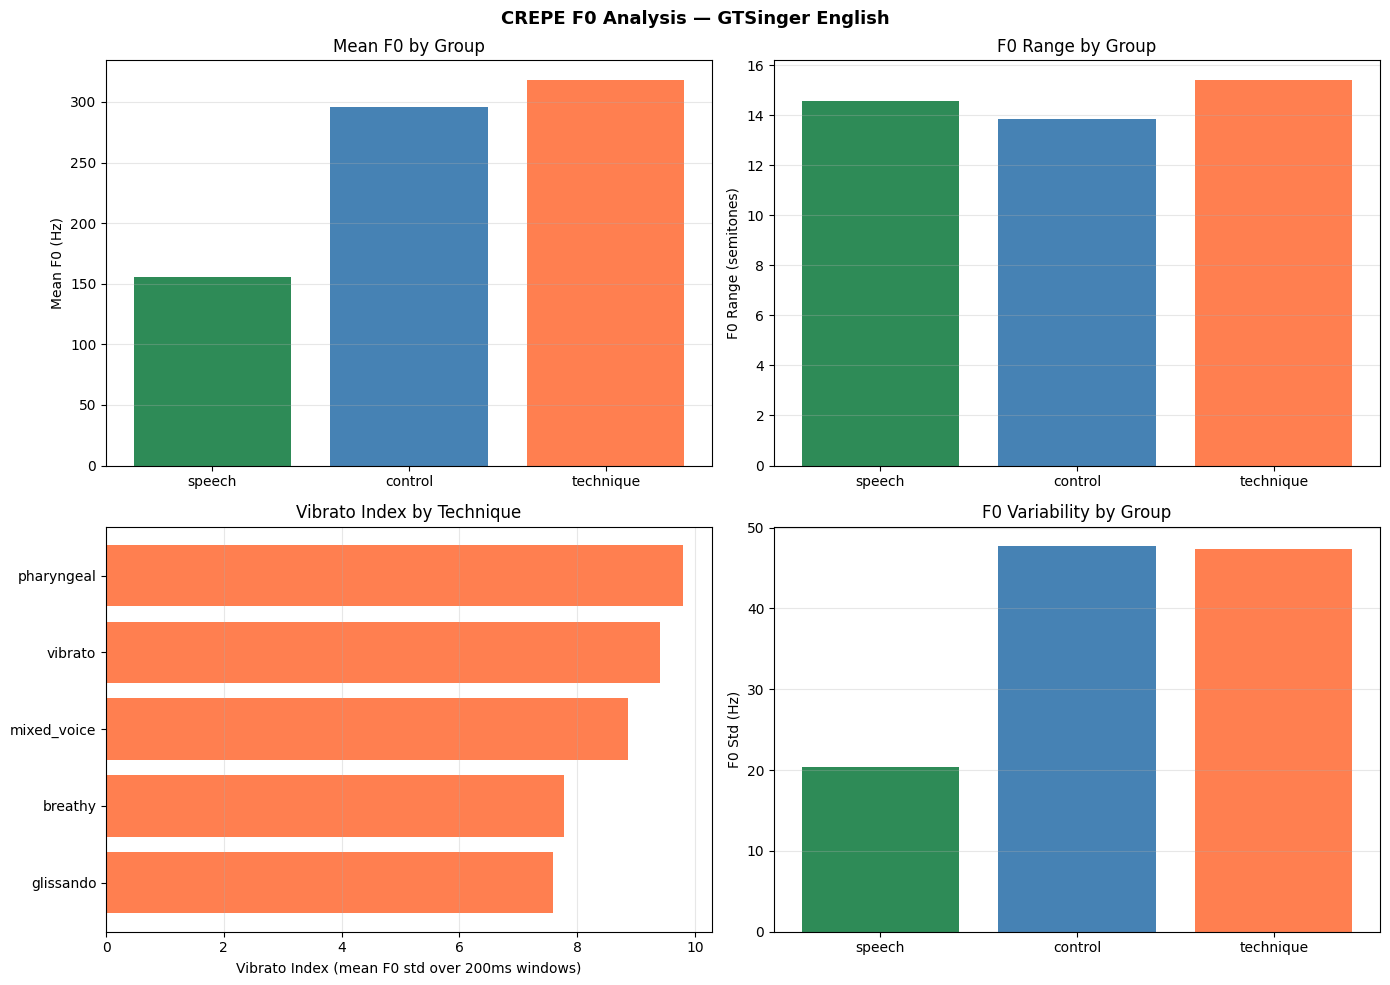

Saved → /content/atlas/crepe_results/f0_statistics.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CREPE F0 Analysis — GTSinger English", fontsize=13, fontweight="bold")

colors = {"control": "steelblue", "technique": "coral", "speech": "seagreen"}

# Plot 1: F0 mean by group
ax = axes[0, 0]
grp = df_f0.groupby("group")["f0_mean_hz"].mean().reindex(["speech", "control", "technique"])
ax.bar(grp.index, grp.values, color=[colors[g] for g in grp.index])
ax.set_ylabel("Mean F0 (Hz)")
ax.set_title("Mean F0 by Group")
ax.grid(axis="y", alpha=0.3)

# Plot 2: F0 range (semitones) by group
ax = axes[0, 1]
grp = df_f0.groupby("group")["f0_range_st"].mean().reindex(["speech", "control", "technique"])
ax.bar(grp.index, grp.values, color=[colors[g] for g in grp.index])
ax.set_ylabel("F0 Range (semitones)")
ax.set_title("F0 Range by Group")
ax.grid(axis="y", alpha=0.3)

# Plot 3: Vibrato index by technique
ax = axes[1, 0]
tech = df_f0[df_f0["group"].isin(["control", "technique"])]\
    .groupby("technique")["vibrato_index"].mean().sort_values(ascending=True)
ax.barh(range(len(tech)), tech.values, color="coral")
ax.set_yticks(range(len(tech)))
ax.set_yticklabels(tech.index)
ax.set_xlabel("Vibrato Index (mean F0 std over 200ms windows)")
ax.set_title("Vibrato Index by Technique")
ax.grid(axis="x", alpha=0.3)

# Plot 4: F0 std by group (pitch variability)
ax = axes[1, 1]
grp = df_f0.groupby("group")["f0_std_hz"].mean().reindex(["speech", "control", "technique"])
ax.bar(grp.index, grp.values, color=[colors[g] for g in grp.index])
ax.set_ylabel("F0 Std (Hz)")
ax.set_title("F0 Variability by Group")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plot_path = CREPE_DIR / "f0_statistics.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")

## 7. F0 Contour Visualisation with Technique Annotations

Plot F0 contour overlaid with phoneme-level technique annotations from TextGrid.

In [ ]:
TECHNIQUE_COLORS = {
    "mix":        "#4CAF50",
    "falsetto":   "#2196F3",
    "breathy":    "#FF9800",
    "pharyngeal": "#9C27B0",
    "vibrato":    "#F44336",
    "glissando":  "#00BCD4",
}

def plot_f0_with_annotations(row, f0_result: dict, title: str = ""):
    """Plot F0 contour with word boundaries and technique annotations."""
    if f0_result is None or row["tg_path"] is None:
        print("No data available")
        return

    try:
        tg = tgt.io.read_textgrid(str(row["tg_path"]))
    except Exception as e:
        print(f"Could not read TextGrid: {e}")
        return

    time       = f0_result["time"]
    f0_voiced  = f0_result["f0_voiced"]
    confidence = f0_result["confidence"]

    # Find tiers
    word_tier  = next((t for t in tg.tiers if t.name == "word"), None)
    tech_tiers = {t.name: t for t in tg.tiers if t.name in TECHNIQUE_COLORS}

    fig, axes = plt.subplots(2, 1, figsize=(16, 7),
                              gridspec_kw={"height_ratios": [3, 1]})
    fig.suptitle(title or row["clean_name"], fontsize=11, fontweight="bold")

    # ── Top: F0 contour ──────────────────────────────────────────────────────
    ax = axes[0]

    # Shade technique regions
    for tech_name, tier in tech_tiers.items():
        intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
        for iv in intervals:
            if iv.text.strip() == "1":
                ax.axvspan(iv.start_time, iv.end_time,
                           alpha=0.2, color=TECHNIQUE_COLORS[tech_name],
                           label=tech_name)

    # Plot F0
    ax.plot(time, f0_voiced, color="black", linewidth=1.5, label="F0 (voiced)")

    # Word boundaries
    if word_tier:
        intervals = word_tier.intervals if hasattr(word_tier, 'intervals') else list(word_tier)
        for iv in intervals:
            ax.axvline(iv.start_time, color="gray", linewidth=0.5, alpha=0.5)
            txt = iv.text.strip()
            if txt and txt.lower() not in ["sil", "sp", "<sp>", "<ap>"]:
                mid = (iv.start_time + iv.end_time) / 2
                ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 500,
                        txt, ha="center", va="top", fontsize=7, color="gray")

    # Legend (deduplicated)
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=8)
    ax.set_ylabel("F0 (Hz)")
    ax.set_xlim(0, time[-1])
    ax.grid(alpha=0.2)

    # ── Bottom: Confidence ───────────────────────────────────────────────────
    ax = axes[1]
    ax.fill_between(time, confidence, alpha=0.5, color="steelblue")
    ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, label="Threshold 0.5")
    ax.set_ylabel("Confidence")
    ax.set_xlabel("Time (s)")
    ax.set_xlim(0, time[-1])
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

print("Visualisation function ready")

Visualisation function ready



GROUP: CONTROL


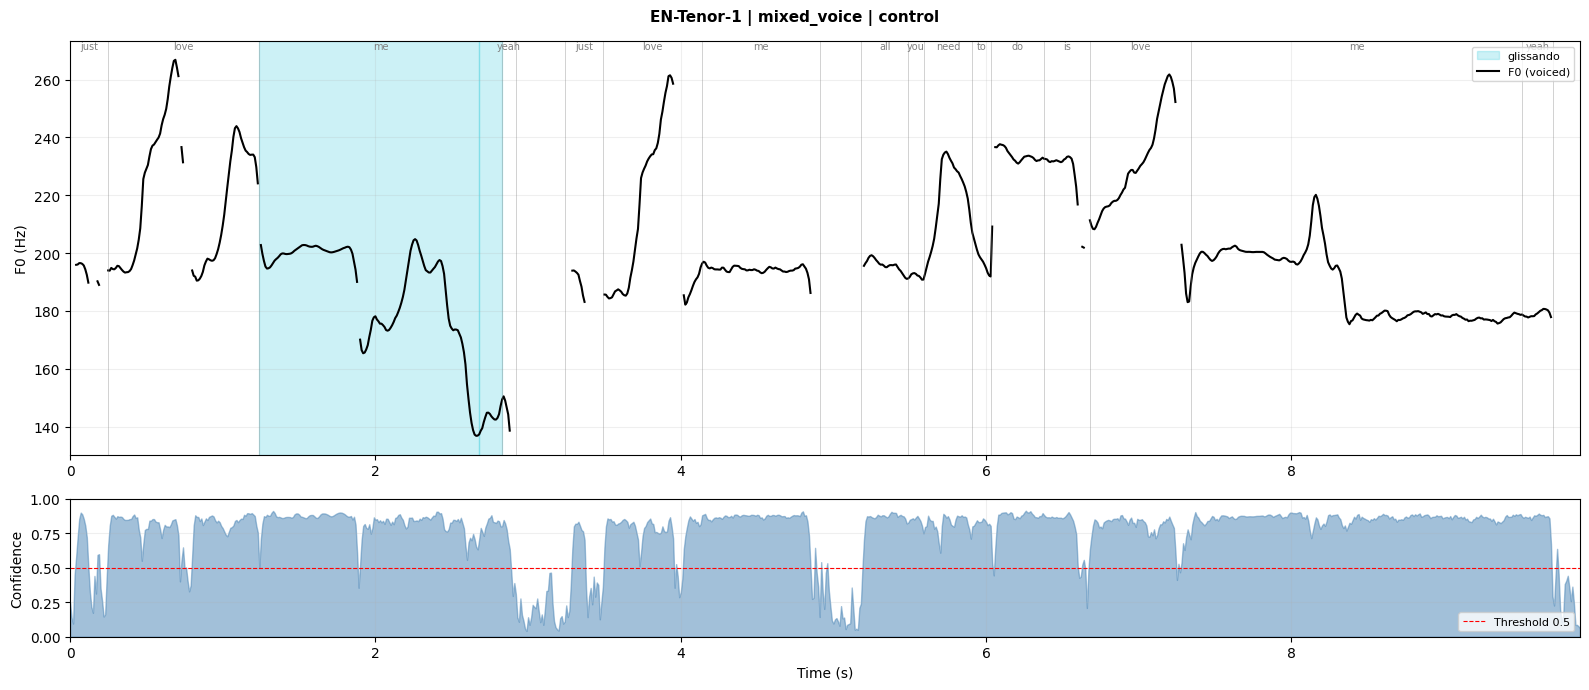


GROUP: SPEECH


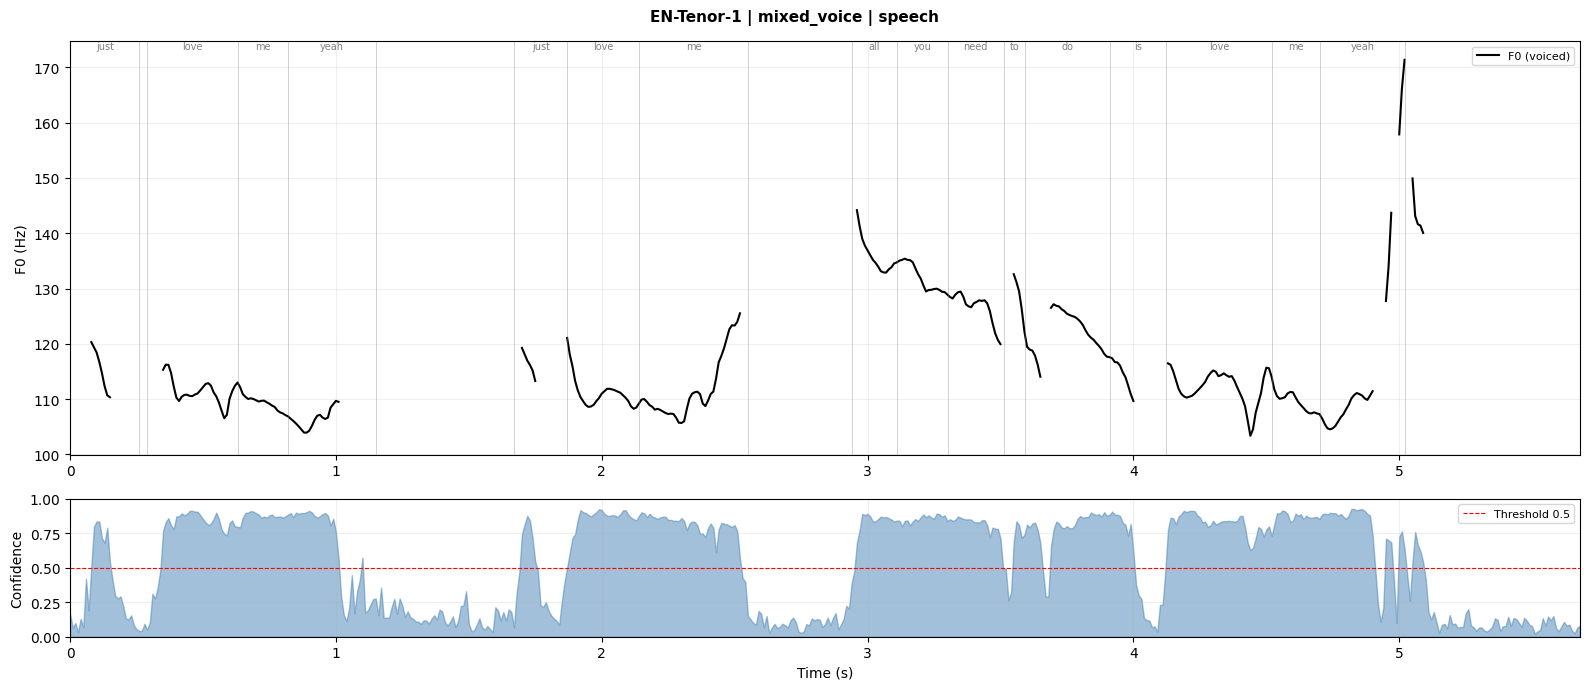


GROUP: TECHNIQUE


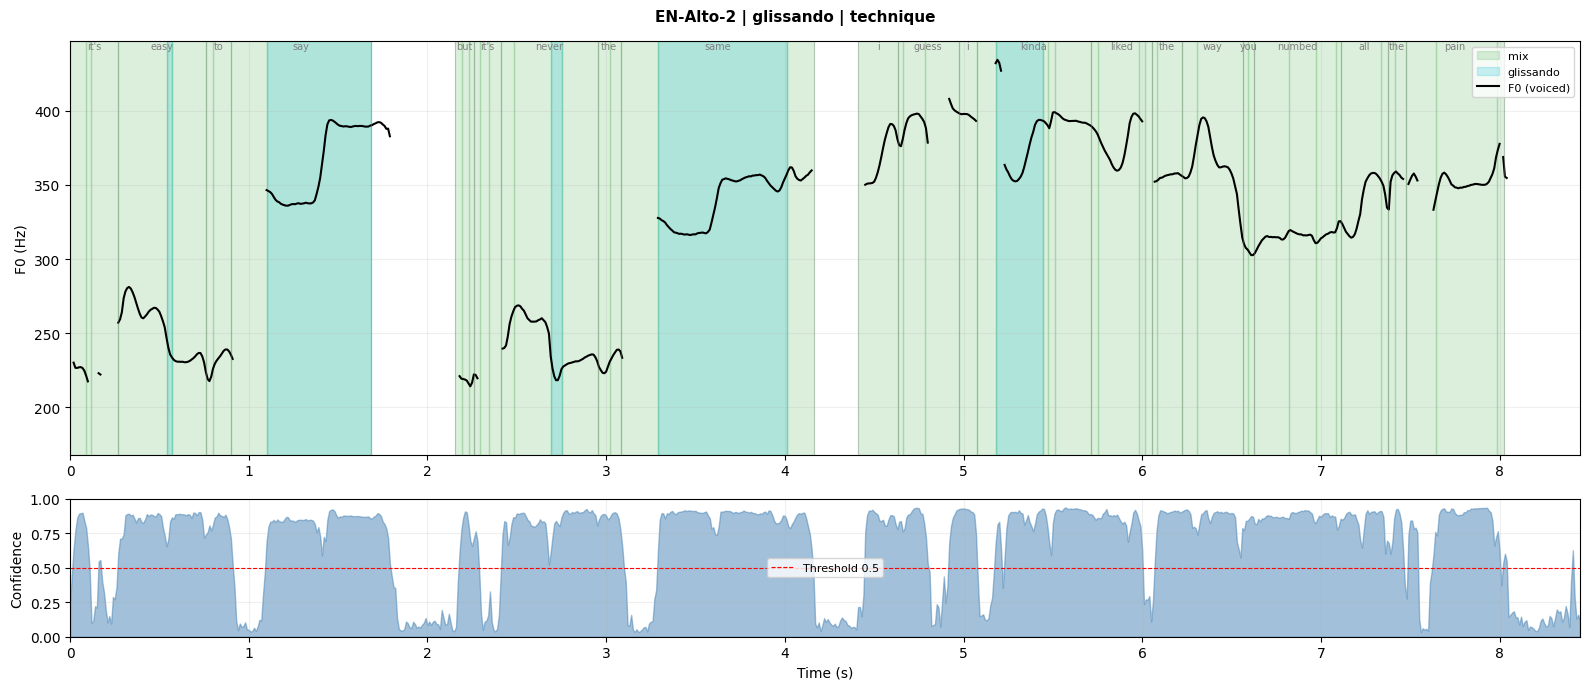

In [ ]:
# Plot one example per group
for group, examples in f0_cache.items():
    print(f"\n{'='*60}")
    print(f"GROUP: {group.upper()}")
    print(f"{'='*60}")
    ex = examples[0]
    plot_f0_with_annotations(
        ex["row"],
        ex["result"],
        title=f"{ex['row']['singer_id']} | {ex['row']['technique']} | {group}"
    )

Selected: EN-Tenor-1__vibrato__control__0007


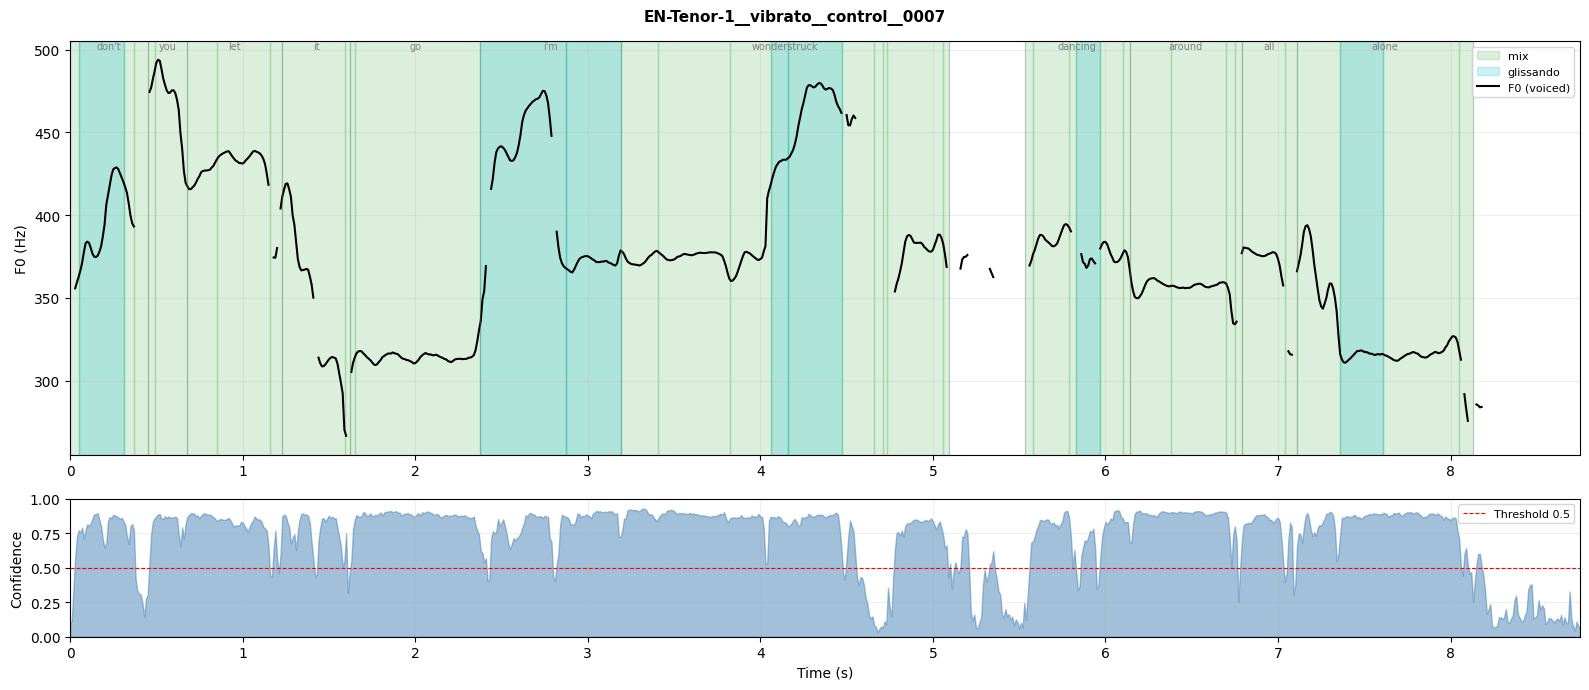

In [ ]:
# Choose a random utterance from df
row = df[
    (df["group"] == "control") &      # change: control/technique/speech
    (df["technique"] == "vibrato")     # change: vibrato/glissando/breathy/etc
].sample(1, random_state=99).iloc[0]  # change random_state

print(f"Selected: {row['clean_name']}")

result = extract_f0(row["wav_path"], model=CREPE_MODEL, step_size=CREPE_STEP)
plot_f0_with_annotations(
    row, result,
    title=f"{row['clean_name']}"
)

## 8. Correlate F0 with Technique Annotations

For each phoneme, extract F0 statistics and check if technique=1 phonemes differ from technique=0.

In [ ]:
TECHNIQUES = ["mix", "falsetto", "breathy", "pharyngeal", "vibrato", "glissando"]

phoneme_records = []

# Use technique group utterances only (they have technique annotations)
technique_df = df[df["group"] == "technique"].head(300)

for _, row in tqdm(technique_df.iterrows(), total=len(technique_df),
                   desc="Correlating F0 with annotations"):
    if not row["tg_path"]:
        continue

    # Extract F0
    result = extract_f0(row["wav_path"], model=CREPE_MODEL, step_size=CREPE_STEP)
    if result is None:
        continue

    try:
        tg = tgt.io.read_textgrid(str(row["tg_path"]))
    except:
        continue

    phone_tier = next((t for t in tg.tiers if t.name == "phone"), None)
    tech_tiers = {t.name: t for t in tg.tiers if t.name in TECHNIQUES}

    if not phone_tier or not tech_tiers:
        continue

    phone_intervals = phone_tier.intervals if hasattr(phone_tier, 'intervals') else list(phone_tier)

    for iv in phone_intervals:
        phone = iv.text.strip()
        if not phone or phone.lower() in ["sil", "sp"]:
            continue

        # Get F0 frames within this phoneme
        mask = (result["time"] >= iv.start_time) & (result["time"] < iv.end_time)
        f0_ph = result["f0_voiced"][mask]
        valid = f0_ph[~np.isnan(f0_ph)]

        if len(valid) < 3:
            continue

        record = {
            "phoneme":    phone,
            "dur_ms":     (iv.end_time - iv.start_time) * 1000,
            "f0_mean":    float(np.mean(valid)),
            "f0_std":     float(np.std(valid)),
            "f0_range":   float(np.max(valid) - np.min(valid)),
            "singer_id":  row["singer_id"],
            "technique":  row["technique"],
        }

        # Get technique labels for this phoneme
        for tech_name, tier in tech_tiers.items():
            tech_intervals = tier.intervals if hasattr(tier, 'intervals') else list(tier)
            tech_iv = next((t for t in tech_intervals
                           if abs(t.start_time - iv.start_time) < 0.01), None)
            record[f"has_{tech_name}"] = int(tech_iv.text.strip() == "1") if tech_iv else 0

        phoneme_records.append(record)

df_ph = pd.DataFrame(phoneme_records)
print(f"\nTotal phoneme instances analysed: {len(df_ph):,}")

Correlating F0 with annotations:   0%|          | 0/66 [00:00<?, ?it/s]


Total phoneme instances analysed: 2,327


In [ ]:
# Compare F0 std (pitch variability) for phonemes with/without each technique
print("F0 variability (std Hz): technique=1 vs technique=0")
print("=" * 55)

for tech in TECHNIQUES:
    col = f"has_{tech}"
    if col not in df_ph.columns:
        continue
    with_tech    = df_ph[df_ph[col] == 1]["f0_std"].mean()
    without_tech = df_ph[df_ph[col] == 0]["f0_std"].mean()
    n_with = (df_ph[col] == 1).sum()
    print(f"  {tech:<12} with=1: {with_tech:6.1f} Hz  "
          f"with=0: {without_tech:6.1f} Hz  "
          f"ratio: {with_tech/without_tech:.2f}x  (n={n_with})")

F0 variability (std Hz): technique=1 vs technique=0
  mix          with=1:    7.2 Hz  with=0:    7.9 Hz  ratio: 0.90x  (n=1242)
  falsetto     with=1:    6.7 Hz  with=0:    7.8 Hz  ratio: 0.86x  (n=620)
  breathy      with=1:    6.5 Hz  with=0:    7.7 Hz  ratio: 0.84x  (n=365)
  pharyngeal   with=1:    8.5 Hz  with=0:    7.4 Hz  ratio: 1.16x  (n=335)
  vibrato      with=1:    8.8 Hz  with=0:    7.5 Hz  ratio: 1.18x  (n=91)
  glissando    with=1:   16.5 Hz  with=0:    6.8 Hz  ratio: 2.44x  (n=178)


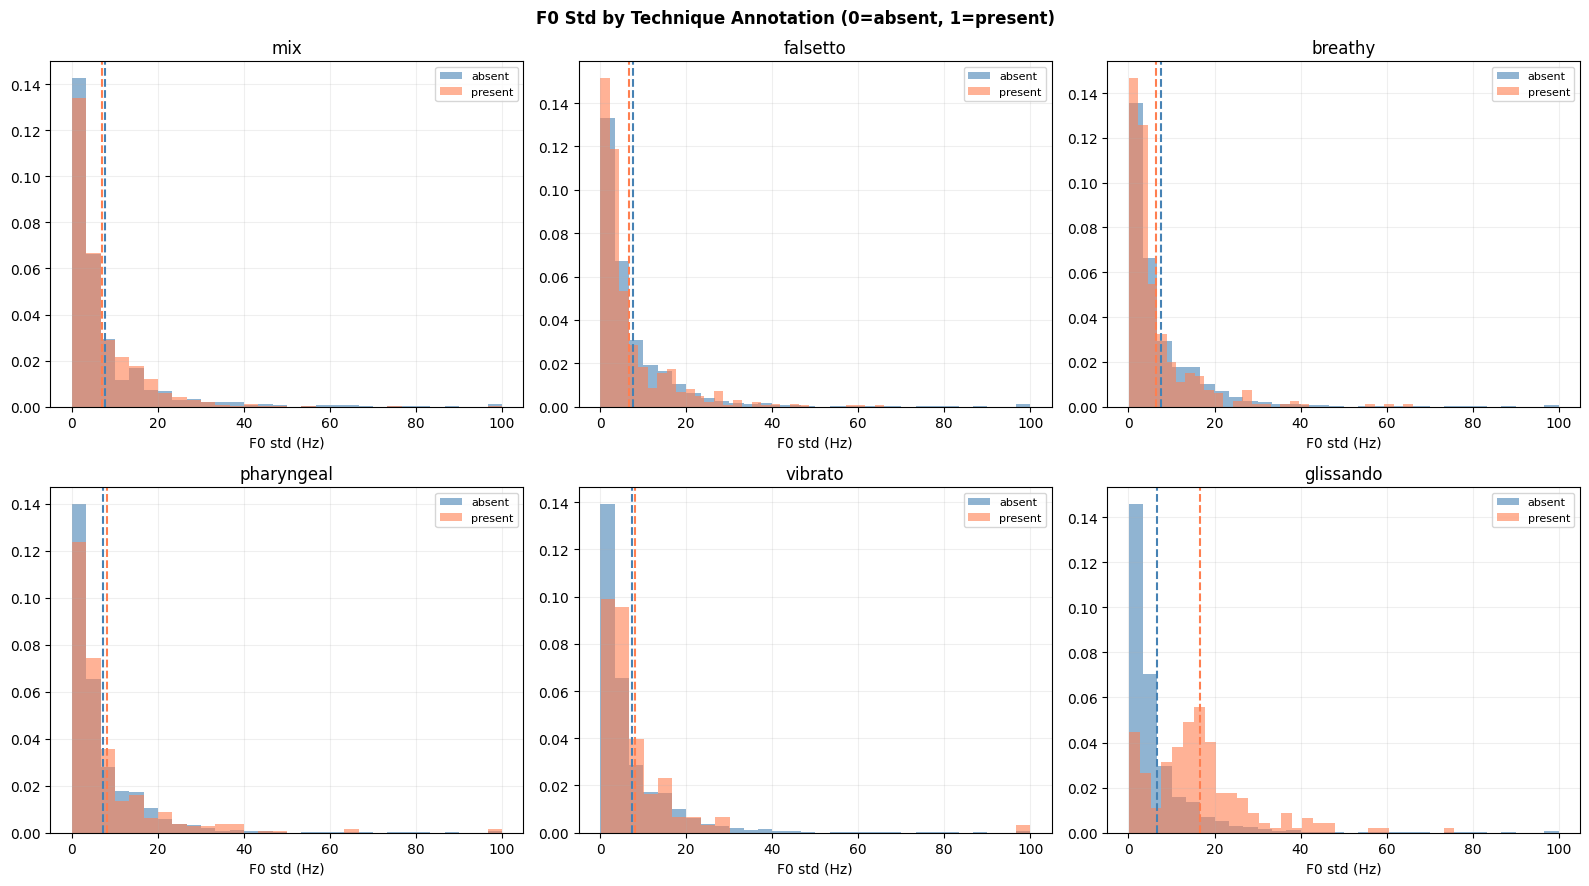

Saved → /content/atlas/crepe_results/f0_technique_correlation.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("F0 Std by Technique Annotation (0=absent, 1=present)",
             fontsize=12, fontweight="bold")

for i, tech in enumerate(TECHNIQUES):
    ax = axes[i // 3][i % 3]
    col = f"has_{tech}"
    if col not in df_ph.columns:
        ax.set_visible(False)
        continue

    data_0 = df_ph[df_ph[col] == 0]["f0_std"].clip(upper=100)
    data_1 = df_ph[df_ph[col] == 1]["f0_std"].clip(upper=100)

    ax.hist(data_0, bins=30, alpha=0.6, color="steelblue", label="absent", density=True)
    ax.hist(data_1, bins=30, alpha=0.6, color="coral",     label="present", density=True)
    ax.axvline(data_0.mean(), color="steelblue", linestyle="--", linewidth=1.5)
    ax.axvline(data_1.mean(), color="coral",     linestyle="--", linewidth=1.5)
    ax.set_title(f"{tech}")
    ax.set_xlabel("F0 std (Hz)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plot_path = CREPE_DIR / "f0_technique_correlation.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {plot_path}")

## 9. Save Results to Drive

In [ ]:
import shutil

# Save F0 statistics
f0_csv = CREPE_DIR / "crepe_f0_statistics.csv"
df_f0.to_csv(f0_csv, index=False)
print(f"F0 statistics → {f0_csv}")

# Save phoneme-level correlation
ph_csv = CREPE_DIR / "crepe_phoneme_f0.csv"
df_ph.to_csv(ph_csv, index=False)
print(f"Phoneme F0 → {ph_csv}")

# Copy to Drive
DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
for f in CREPE_DIR.iterdir():
    if f.suffix in [".csv", ".png"]:
        shutil.copy2(f, DRIVE_RESULTS / f.name)
        print(f"{f.name} → Drive")

print("\nAll done!")

F0 statistics → /content/atlas/crepe_results/crepe_f0_statistics.csv
Phoneme F0 → /content/atlas/crepe_results/crepe_phoneme_f0.csv
crepe_f0_statistics.csv → Drive
f0_technique_correlation.png → Drive
f0_statistics.png → Drive
crepe_phoneme_f0.csv → Drive

All done!
